TASK 1: LOAD cleaned_data.csv

In [21]:
import pandas as pd

df = pd.read_csv('/content/cleaned_data.csv')

print("Dataset loaded successfully")
print(df.shape)

Dataset loaded successfully
(1460, 81)


In [22]:
X = df.drop(columns=['SalePrice'])

y_reg = df['SalePrice']

saleprice_median = y_reg.median()
y_clf =(y_reg > y_reg.median()).astype(int)

print("TASK 1: FEATURE MATRIX AND TARGET LABELS")
print("=" * 50)

print("\nFeature matrix X shape:", X.shape)
print("Regression label y_reg shape:", y_reg.shape)
print("Classification label y_clf shape:", y_clf.shape)

print("\nRegression target: SalePrice")
print("SalePrice median:", saleprice_median)

print("\nClassification target definition:")
print("0 = SalePrice less than or equal to the median")
print("1 = SalePrice greater than the median")

print("\nClassification label counts:")
print(y_clf.value_counts().sort_index())

TASK 1: FEATURE MATRIX AND TARGET LABELS

Feature matrix X shape: (1460, 80)
Regression label y_reg shape: (1460,)
Classification label y_clf shape: (1460,)

Regression target: SalePrice
SalePrice median: 163000.0

Classification target definition:
0 = SalePrice less than or equal to the median
1 = SalePrice greater than the median

Classification label counts:
SalePrice
0    732
1    728
Name: count, dtype: int64


TASK 2: ENCODE CATEGORICAL COLUMNS

In [23]:
categorical_columns = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("TASK 2: CATEGORICAL COLUMNS")
print("=" * 50)

print("\nNumber of categorical columns:", len(categorical_columns))

print("\nCategorical columns:")
for col in categorical_columns:
    print(col)

TASK 2: CATEGORICAL COLUMNS

Number of categorical columns: 43

Categorical columns:
MSZoning
Street
Alley
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
PoolQC
Fence
MiscFeature
SaleType
SaleCondition


In [24]:
X_encoded = X.copy()

quality_mapping = {
    'Po': 0,
    'Fa': 1,
    'TA': 2,
    'Gd': 3,
    'Ex': 4
}

ordinal_columns = [
    'ExterQual',
    'ExterCond',
    'HeatingQC',
    'KitchenQual'
]

for col in ordinal_columns:
    X_encoded[col] = X_encoded[col].map(quality_mapping)

remaining_categorical_columns = [
    col for col in categorical_columns
    if col not in ordinal_columns
]

X_encoded = pd.get_dummies(
    X_encoded,
    columns=remaining_categorical_columns,
    drop_first=True,
    dtype=int
)

print("TASK 2: CATEGORICAL ENCODING")
print("=" * 50)

print("\nOrdinal columns encoded using natural order:")
for col in ordinal_columns:
    print(col)

print("\nOrdinal mapping:")
print("Po = 0, Fa = 1, TA = 2, Gd = 3, Ex = 4")

print("\nNumber of nominal columns one-hot encoded:",
      len(remaining_categorical_columns))

print("\nOriginal X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

print("\nRemaining categorical columns:",
      X_encoded.select_dtypes(include=['object', 'category']).shape[1])

TASK 2: CATEGORICAL ENCODING

Ordinal columns encoded using natural order:
ExterQual
ExterCond
HeatingQC
KitchenQual

Ordinal mapping:
Po = 0, Fa = 1, TA = 2, Gd = 3, Ex = 4

Number of nominal columns one-hot encoded: 39

Original X shape: (1460, 80)
Encoded X shape: (1460, 235)

Remaining categorical columns: 0


In [25]:
print("MISSING VALUES AFTER ENCODING")
print("=" * 50)

total_missing = X_encoded.isnull().sum().sum()

print("\nTotal missing values in X_encoded:", total_missing)

missing_columns = X_encoded.columns[X_encoded.isnull().any()].tolist()

print("\nColumns with missing values:")
print(missing_columns)

MISSING VALUES AFTER ENCODING

Total missing values in X_encoded: 0

Columns with missing values:
[]


TASK 3: LEAK-FREE TRAIN-TEST SPLIT AND SCALING

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X_encoded,
    y_reg,
    y_clf,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("TASK 3: TRAIN-TEST SPLIT AND SCALING")
print("=" * 50)

print("\nTraining feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)

print("\nRegression training label shape:", y_reg_train.shape)
print("Regression test label shape:", y_reg_test.shape)

print("\nClassification training label shape:", y_clf_train.shape)
print("Classification test label shape:", y_clf_test.shape)

print("\nScaled training feature shape:", X_train_scaled.shape)
print("Scaled test feature shape:", X_test_scaled.shape)

print("\nScaler fitted only on training features")
print("Training and test features transformed successfully")

TASK 3: TRAIN-TEST SPLIT AND SCALING

Training feature shape: (1168, 235)
Test feature shape: (292, 235)

Regression training label shape: (1168,)
Regression test label shape: (292,)

Classification training label shape: (1168,)
Classification test label shape: (292,)

Scaled training feature shape: (1168, 235)
Scaled test feature shape: (292, 235)

Scaler fitted only on training features
Training and test features transformed successfully


TASK 4: REGRESSION MODEL- LINEAR REGRESSION

In [27]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_reg_train)

y_pred_reg = linear_model.predict(X_test_scaled)

linear_mse = mean_squared_error(y_reg_test, y_pred_reg)
linear_r2 = r2_score(y_reg_test, y_pred_reg)

coefficients = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': linear_model.coef_
})

coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()

top_3_features = coefficients.nlargest(
    3,
    'Absolute_Coefficient'
)

print("TASK 4: LINEAR REGRESSION")
print("=" * 60)

print("\nLinear Regression MSE:")
print(linear_mse)

print("\nLinear Regression R²:")
print(linear_r2)

print("\nModel coefficients with corresponding feature names:")
print(coefficients[['Feature', 'Coefficient']].to_string(index=False))

print("\nTop 3 features with the largest absolute coefficient values:")
print(
    top_3_features[
        ['Feature', 'Coefficient', 'Absolute_Coefficient']
    ].to_string(index=False)
)

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_reg_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_reg_test, y_pred_ridge)
ridge_r2 = r2_score(y_reg_test, y_pred_ridge)

comparison_table = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression'
    ],
    'MSE': [
        linear_mse,
        ridge_mse
    ],
    'R²': [
        linear_r2,
        ridge_r2
    ]
})

print("\nLinear Regression vs Ridge Regression:")
print(comparison_table.to_string(index=False))

TASK 4: LINEAR REGRESSION

Linear Regression MSE:
2480296419.0764894

Linear Regression R²:
0.6766374268733913

Model coefficients with corresponding feature names:
              Feature   Coefficient
                   Id  4.915581e+02
           MSSubClass  1.581646e+03
          LotFrontage -1.468673e+02
              LotArea  7.212101e+03
          OverallQual  9.579652e+03
          OverallCond  6.522660e+03
            YearBuilt  1.066926e+04
         YearRemodAdd  1.598585e+03
           MasVnrArea  4.542671e+03
            ExterQual  1.769725e+03
            ExterCond -9.269933e+02
           BsmtFinSF1  9.215759e+03
           BsmtFinSF2  1.676844e+03
            BsmtUnfSF  1.351721e+03
          TotalBsmtSF  1.157165e+04
            HeatingQC -3.163018e+02
             1stFlrSF  3.655700e+03
             2ndFlrSF  1.225537e+04
         LowQualFinSF -1.221316e+03
            GrLivArea  1.285616e+04
         BsmtFullBath  1.065004e+03
         BsmtHalfBath -5.350435e+02
       

TASK 5: CLASSIFICATION MODEL- LOGISTIC REGRESSION

TASK 5: LOGISTIC REGRESSION

Training class counts:
SalePrice
0    571
1    597
Name: count, dtype: int64

Training class percentages:
SalePrice
0    48.89
1    51.11
Name: proportion, dtype: float64

No significant class imbalance detected.
No imbalance treatment is required.

Before/After Class Count Comparison:
           Before Treatment  After Treatment
SalePrice                                   
0                       571              571
1                       597              597

The counts are unchanged because both classes exceed the 35% threshold, so no imbalance treatment was required.

Confusion Matrix:
[[148  13]
 [  5 126]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       161
           1       0.91      0.96      0.93       131

    accuracy                           0.94       292
   macro avg       0.94      0.94      0.94       292
weighted avg       0.94      0.94      0.94       292

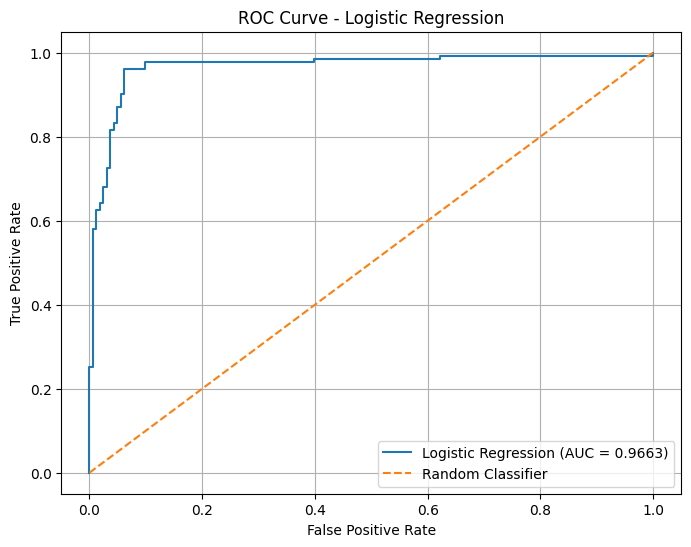

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt

print("TASK 5: LOGISTIC REGRESSION")
print("=" * 60)

print("\nTraining class counts:")
print(y_clf_train.value_counts().sort_index())

print("\nTraining class percentages:")
print((y_clf_train.value_counts(normalize=True).sort_index() * 100).round(2))

minority_percentage = y_clf_train.value_counts(normalize=True).min() * 100

if minority_percentage < 35:
    print("\nClass imbalance detected.")
    print("Using class_weight='balanced'.")

    logistic_model = LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    )
else:
    print("\nNo significant class imbalance detected.")
    print("No imbalance treatment is required.")

    logistic_model = LogisticRegression(
        max_iter=1000
    )
print("\nBefore/After Class Count Comparison:")

class_count_comparison = pd.DataFrame({
    "Before Treatment": y_clf_train.value_counts().sort_index(),
    "After Treatment": y_clf_train.value_counts().sort_index()
})

print(class_count_comparison)

print(
    "\nThe counts are unchanged because both classes exceed "
    "the 35% threshold, so no imbalance treatment was required."
)

logistic_model.fit(X_train_scaled, y_clf_train)

y_pred_clf = logistic_model.predict(X_test_scaled)

y_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

conf_matrix = confusion_matrix(y_clf_test, y_pred_clf)

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred_clf))

fpr, tpr, thresholds = roc_curve(
    y_clf_test,
    y_pred_proba
)

auc_value = roc_auc_score(
    y_clf_test,
    y_pred_proba
)

print("\nAUC Score:")
print(auc_value)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc_value:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid()

plt.savefig(
    'roc_curve.png',
    bbox_inches='tight'
)

plt.show()

b) DECISION- THRESHOLD SENSITIVITY

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

print("TASK 5(b): DECISION-THRESHOLD SENSITIVITY")
print("=" * 60)

# Generate probabilities for Class 1
y_clf_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Thresholds required in the question
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:

    # Convert probabilities into class predictions
    y_pred_threshold = (y_clf_proba >= threshold).astype(int)

    # Calculate metrics
    precision = precision_score(y_clf_test, y_pred_threshold)
    recall = recall_score(y_clf_test, y_pred_threshold)
    f1 = f1_score(y_clf_test, y_pred_threshold)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

# Create results table
threshold_table = pd.DataFrame(threshold_results)

print("\nThreshold Sensitivity Results:")
print(threshold_table.to_string(index=False))

# Find threshold with maximum F1-score
best_row = threshold_table.loc[threshold_table["F1"].idxmax()]

print("\nBest Threshold Based on F1-Score:")
print("Threshold:", best_row["Threshold"])
print("Precision:", best_row["Precision"])
print("Recall:", best_row["Recall"])
print("F1-Score:", best_row["F1"])

TASK 5(b): DECISION-THRESHOLD SENSITIVITY

Threshold Sensitivity Results:
 Threshold  Precision   Recall       F1
       0.3   0.870748 0.977099 0.920863
       0.4   0.887324 0.961832 0.923077
       0.5   0.906475 0.961832 0.933333
       0.6   0.906475 0.961832 0.933333
       0.7   0.919708 0.961832 0.940299

Best Threshold Based on F1-Score:
Threshold: 0.7
Precision: 0.9197080291970803
Recall: 0.9618320610687023
F1-Score: 0.9402985074626866


TASK 6: REGULARIZATION EXPERIMENT ON LOGISTIC REGRESSION

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score
import pandas as pd

print("TASK 6: REGULARIZATION EXPERIMENT")
print("=" * 60)

# Baseline model already trained in Task 5
# C = 1.0 is the default Logistic Regression regularization strength

baseline_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]
baseline_pred = logistic_model.predict(X_test_scaled)

baseline_precision = precision_score(y_clf_test, baseline_pred)
baseline_recall = recall_score(y_clf_test, baseline_pred)
baseline_auc = roc_auc_score(y_clf_test, baseline_proba)

# Train second Logistic Regression model with strong regularization
strong_reg_model = LogisticRegression(
    C=0.01,
    max_iter=1000
)

strong_reg_model.fit(X_train_scaled, y_clf_train)

# Predictions and probabilities
strong_reg_pred = strong_reg_model.predict(X_test_scaled)
strong_reg_proba = strong_reg_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
strong_reg_precision = precision_score(y_clf_test, strong_reg_pred)
strong_reg_recall = recall_score(y_clf_test, strong_reg_pred)
strong_reg_auc = roc_auc_score(y_clf_test, strong_reg_proba)

# Comparison table
regularization_table = pd.DataFrame({
    "Model": ["Baseline (C=1.0)", "Strong Regularization (C=0.01)"],
    "Precision": [baseline_precision, strong_reg_precision],
    "Recall": [baseline_recall, strong_reg_recall],
    "AUC": [baseline_auc, strong_reg_auc]
})

print("\nRegularization Comparison:")
print(regularization_table.to_string(index=False))

TASK 6: REGULARIZATION EXPERIMENT

Regularization Comparison:
                         Model  Precision   Recall      AUC
              Baseline (C=1.0)   0.906475 0.961832 0.966336
Strong Regularization (C=0.01)   0.940741 0.969466 0.980466


TASK 7: BOOTSTRAP CONFIDENCE INTERVAL FOR AUC DIFFERENCE

In [33]:
import numpy as np
from sklearn.metrics import roc_auc_score

print("TASK 7: BOOTSTRAP CONFIDENCE INTERVAL FOR AUC DIFFERENCE")
print("=" * 70)

# Predicted probabilities from both Task 6 models
baseline_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]
strong_reg_proba = strong_reg_model.predict_proba(X_test_scaled)[:, 1]

# Store the AUC difference from each bootstrap sample
auc_differences = []

# Set seed for reproducible results
np.random.seed(42)

# Draw exactly 500 bootstrap samples
for i in range(500):

    # Sample test-set row indices with replacement
    sample_indices = np.random.choice(
        len(y_clf_test),
        size=len(y_clf_test),
        replace=True
    )

    # Get the sampled true labels
    y_sample = y_clf_test.iloc[sample_indices]

    # Skip a sample if it contains only one class
    if len(np.unique(y_sample)) < 2:
        continue

    # Get predicted probabilities for the same sampled rows
    baseline_sample_proba = baseline_proba[sample_indices]
    strong_reg_sample_proba = strong_reg_proba[sample_indices]

    # Compute AUC for both models
    baseline_sample_auc = roc_auc_score(
        y_sample,
        baseline_sample_proba
    )

    strong_reg_sample_auc = roc_auc_score(
        y_sample,
        strong_reg_sample_proba
    )

    # Required difference: AUC of C=1.0 minus AUC of C=0.01
    auc_difference = baseline_sample_auc - strong_reg_sample_auc

    auc_differences.append(auc_difference)

# Convert results to NumPy array
auc_differences = np.array(auc_differences)

# Compute required bootstrap statistics
mean_auc_difference = np.mean(auc_differences)

lower_bound = np.percentile(auc_differences, 2.5)
upper_bound = np.percentile(auc_differences, 97.5)

# Print results
print("\nNumber of bootstrap samples:", len(auc_differences))
print("Mean AUC difference (C=1.0 - C=0.01):", mean_auc_difference)
print("95% Confidence Interval:")
print("Lower bound (2.5th percentile):", lower_bound)
print("Upper bound (97.5th percentile):", upper_bound)

# Check whether the confidence interval excludes zero
if lower_bound > 0:
    print("\nThe 95% confidence interval excludes zero.")
    print("Because the entire interval is positive, the C=1.0 model")
    print("consistently outperforms the C=0.01 model in AUC.")

elif upper_bound < 0:
    print("\nThe 95% confidence interval excludes zero.")
    print("Because the entire interval is negative, the C=0.01 model")
    print("consistently outperforms the C=1.0 model in AUC.")

else:
    print("\nThe 95% confidence interval includes zero.")
    print("The performance difference may not be reliable")
    print("across different data samples.")

TASK 7: BOOTSTRAP CONFIDENCE INTERVAL FOR AUC DIFFERENCE

Number of bootstrap samples: 500
Mean AUC difference (C=1.0 - C=0.01): -0.014823781355875948
95% Confidence Interval:
Lower bound (2.5th percentile): -0.03009047807587633
Upper bound (97.5th percentile): -0.0023875105891979385

The 95% confidence interval excludes zero.
Because the entire interval is negative, the C=0.01 model
consistently outperforms the C=1.0 model in AUC.
